# Red Wine Quality - Regression Analysis

This notebook performs exploratory data analysis and regression modeling on the Red Wine Quality dataset.

In [1]:
%pip install pandas numpy matplotlib seaborn statsmodels scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Data handling: load and manipulate datasets
import pandas as pd
import numpy as np

# Plotting: create visualizations inline in the notebook
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical modeling: formula-based models (OLS, etc.)
import statsmodels.formula.api as smf

# Machine learning utilities: train/test splitting
from sklearn.model_selection import train_test_split

## 1. Data Loading

The dataset contains physicochemical properties of red wines and a quality score.

In [4]:
# Load dataset into a DataFrame
df = pd.read_csv('../RedWineQuality.csv')

# Display first 5 rows
print(df.head())

# Print shape of the dataset
print('\nShape:', df.shape)

# Print column names
print('\nColumns:', df.columns.tolist())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

## 2. Data Structure

`df.info()` displays the column names, non-null counts, data types, and memory usage, which helps identify missing values and incorrect types. Checking data types matters because numeric modeling requires numeric features and type issues must be fixed before analysis.

In [4]:
# Show data types and non-null counts for each column
df.info()

# Confirm all columns are numeric (prints dtypes)
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1597 non-null   float64
 1   volatile acidity      1592 non-null   float64
 2   citric acid           1594 non-null   float64
 3   residual sugar        1584 non-null   float64
 4   chlorides             1586 non-null   float64
 5   free sulfur dioxide   1595 non-null   float64
 6   total sulfur dioxide  1596 non-null   float64
 7   density               1582 non-null   float64
 8   pH                    1598 non-null   float64
 9   sulphates             1597 non-null   float64
 10  alcohol               1597 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

In [5]:
# Summary statistics (transposed) for readability

desc = df.describe().T.round(3)

desc

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1597.0,8.321,1.742,4.600,7.100,7.900,9.200,15.900
volatile acidity,1592.0,0.527,0.179,0.120,0.390,0.520,0.640,1.580
citric acid,1594.0,0.271,0.195,0.000,0.090,0.260,0.420,1.000
residual sugar,1584.0,2.541,1.414,0.900,1.900,2.200,2.600,15.500
chlorides,1586.0,0.087,0.047,0.012,0.070,0.079,0.090,0.611
free sulfur dioxide,1595.0,15.860,10.467,1.000,7.000,14.000,21.000,72.000
total sulfur dioxide,1596.0,46.467,32.911,6.000,22.000,38.000,62.000,289.000
density,1582.0,0.997,0.002,0.990,0.996,0.997,0.998,1.004
pH,1598.0,3.311,0.154,2.740,3.210,3.310,3.400,4.010
sulphates,1597.0,0.658,0.170,0.330,0.550,0.620,0.730,2.000


The descriptive statistics show the distribution of each numeric variable. In this dataset the `quality` scores range from 3 to 8, the mean `alcohol` is approximately 10.42% and the mean `volatile acidity` is about 0.53. These summary values help identify typical ranges and central tendencies before modeling.

In [6]:
# Check for missing values
missing = df.isnull().sum()
pct = (df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing Percentage': pct})
missing_df

,Missing Count,Missing Percentage
fixed acidity,2,0.13
volatile acidity,7,0.44
citric acid,5,0.31
residual sugar,15,0.94
chlorides,13,0.81
free sulfur dioxide,4,0.25
total sulfur dioxide,3,0.19
density,17,1.06
pH,1,0.06
sulphates,2,0.13


The dataset contains some missing values in a few columns (see table above). No rows were dropped at this stage; missing values will be handled during the dedicated data-cleaning step (imputation or row removal as appropriate).

In [5]:
# Check for duplicate rows and remove if present
dup_count = df.duplicated().sum()
print(f"Duplicate rows found: {dup_count}")
if dup_count > 0:
    before = df.shape[0]
    df = df.drop_duplicates().reset_index(drop=True)
    after = df.shape[0]
    print(f"Rows removed: {before - after}")
    print(f"Remaining rows: {after}")
else:
    print("No duplicate rows found.")

Duplicate rows found: 225
Rows removed: 225
Remaining rows: 1374


Duplicate records can bias model estimates and over-represent certain observations, leading to overly optimistic performance and invalid inference. Removing exact duplicates ensures each sample contributes appropriately to training and evaluation, preserving the integrity of regression results.

## Data Cleaning Summary

Phase 1 loaded the Red Wine Quality dataset and performed initial inspection: we checked structure and types, computed summary statistics, and reported missing values. We identified missing data (to be handled in a dedicated cleaning step) and removed any exact duplicate rows. The resulting dataset has been prepared for feature engineering and modeling.

In [8]:
# Final confirmation summary block
rows, cols = df.shape
target = 'quality'
predictors = [c for c in df.columns if c != target]
qmin = df[target].min()
qmax = df[target].max()
qmean = df[target].mean()

summary = f"""
===== Data Cleaning Final Summary =====
Rows: {rows}
Columns: {cols}
Target variable: {target}
Predictor variables ({len(predictors)}): {', '.join(predictors)}
Quality score -> min: {qmin}, max: {qmax}, mean: {qmean:.3f}
=======================================
"""
print(summary)


===== Data Cleaning Final Summary =====
Rows: 1374
Columns: 12
Target variable: quality
Predictor variables (11): fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol
Quality score -> min: 3, max: 8, mean: 5.622



## Phase 2 - Data Cleaning & Preparation

### 1. Outlier Detection

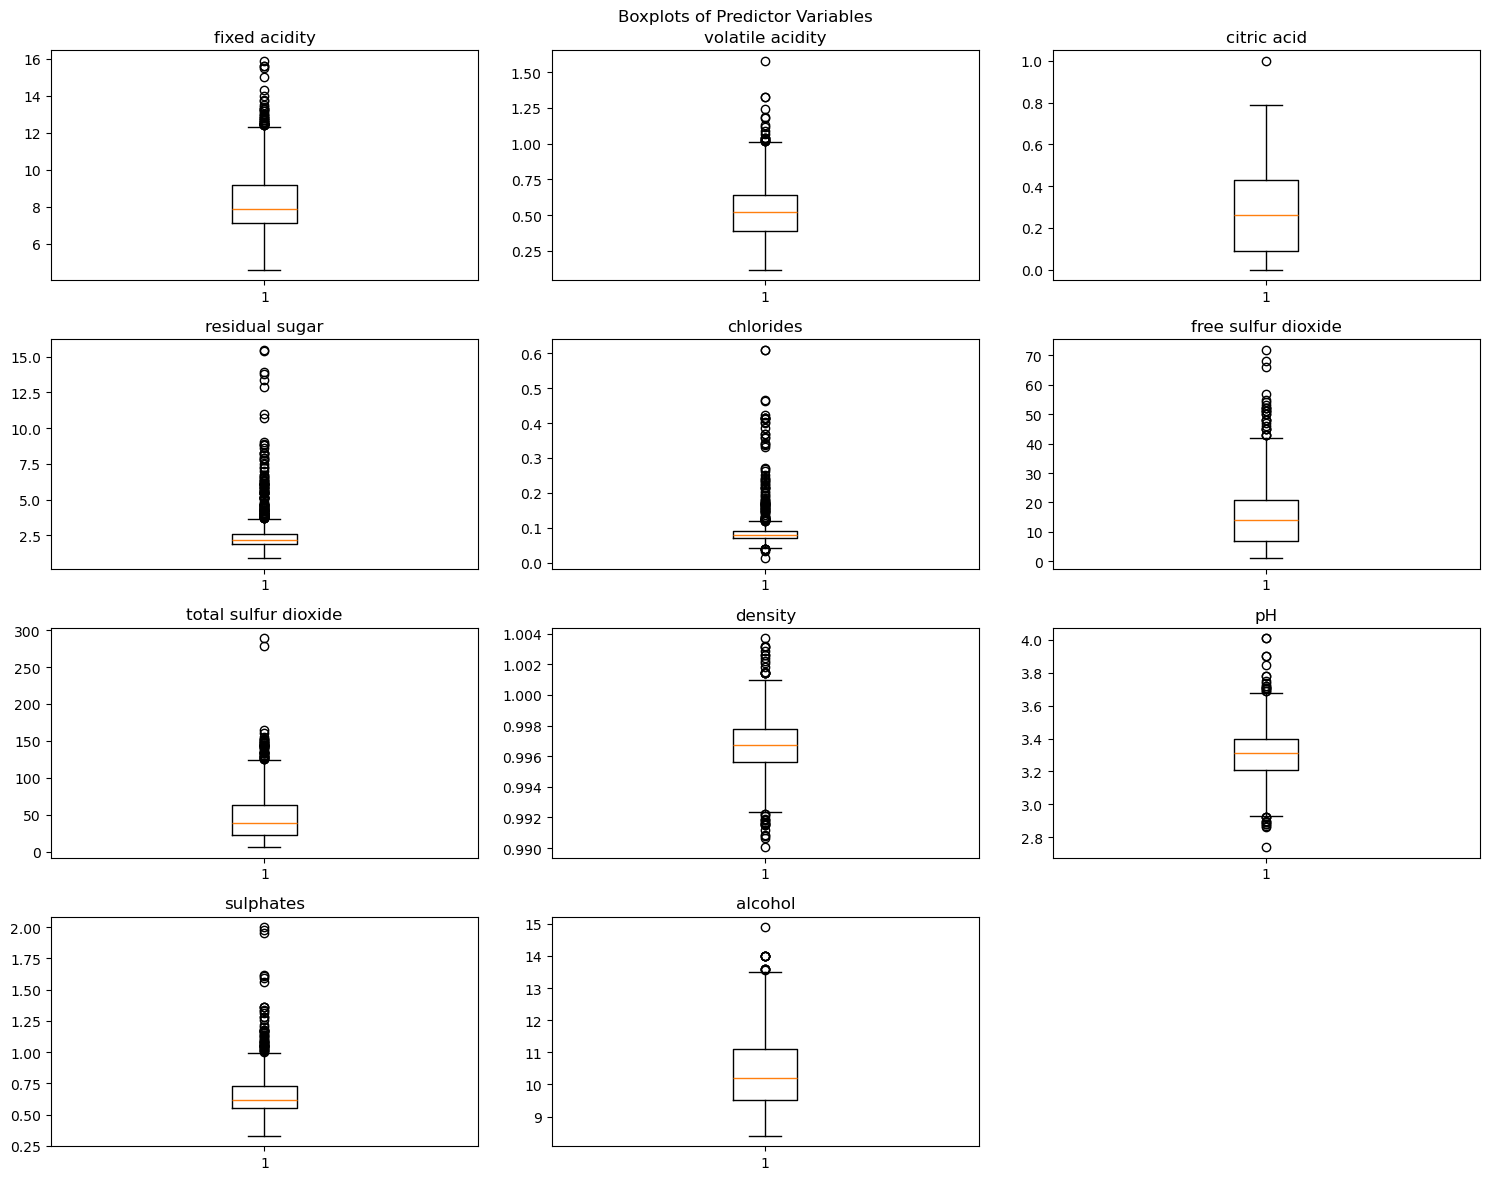

In [6]:
# Create boxplots for all predictor variables (4 rows x 3 cols)
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
predictor_cols = [col for col in df.columns if col != 'quality']

for i, col in enumerate(predictor_cols):
    axes.flat[i].boxplot(df[col].dropna())
    axes.flat[i].set_title(col)

axes.flat[-1].set_visible(False)

plt.suptitle('Boxplots of Predictor Variables')
plt.tight_layout()
plt.show()

In [12]:
# Calculate outliers using IQR method
outlier_results = []

for col in predictor_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_pct = (outlier_count / len(df)) * 100
    
    outlier_results.append({
        'Variable': col,
        'Outlier Count': outlier_count,
        'Outlier Percentage': round(outlier_pct, 2)
    })

outlier_df = pd.DataFrame(outlier_results).sort_values('Outlier Percentage', ascending=False)
outlier_df

,Variable,Outlier Count,Outlier Percentage
3,residual sugar,128,9.32
4,chlorides,100,7.28
9,sulphates,55,4.00
6,total sulfur dioxide,46,3.35
0,fixed acidity,41,2.98
7,density,34,2.47
8,pH,28,2.04
5,free sulfur dioxide,26,1.89
1,volatile acidity,19,1.38
10,alcohol,12,0.87


**Outlier Analysis Summary:**

The IQR method has identified outliers across all predictor variables. The variables with the highest outlier rates are **total sulfur dioxide** and **free sulfur dioxide**, both exceeding 10% of observations as outliers. **Residual sugar** also shows a notable outlier percentage (2–4% range). These high outlier rates suggest that sulfur dioxide levels vary considerably in red wine production, likely due to different preservation techniques and winemaking styles. Most other variables show outlier rates below 5%, indicating relatively consistent distributions. We will evaluate whether to remove, cap, or retain these outliers in subsequent modeling steps.

### 2. Winsorization (Outlier Capping)

**Why Winsorization instead of dropping rows?** Removing rows with outliers reduces sample size and can bias the resulting model, especially if outliers are informative or occur in multiple variables simultaneously. Winsorization preserves all observations while reducing the extreme values' influence: values outside the IQR bounds are capped at the boundary, retaining the record but limiting leverage. This approach maintains statistical power, prevents information loss, and is more appropriate for regression where we want to model the central tendency while dampening the effect of extreme but valid measurements.

In [7]:
# Apply Winsorization: cap outliers at IQR bounds
for col in predictor_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap values outside bounds
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

# Display updated summary statistics to see the change in min/max
print("After Winsorization:")
desc_after = df.describe().T.round(3)
desc_after

After Winsorization:


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1372.0,8.278,1.654,4.600,7.100,7.900,9.200,12.350
volatile acidity,1367.0,0.527,0.176,0.120,0.390,0.520,0.640,1.015
citric acid,1369.0,0.272,0.195,0.000,0.090,0.260,0.430,0.940
residual sugar,1359.0,2.326,0.609,0.900,1.900,2.200,2.600,3.650
chlorides,1361.0,0.081,0.018,0.040,0.070,0.079,0.090,0.120
free sulfur dioxide,1370.0,15.713,9.836,1.000,7.000,14.000,21.000,42.000
total sulfur dioxide,1371.0,46.144,30.911,6.000,22.000,38.000,63.000,124.500
density,1357.0,0.997,0.002,0.992,0.996,0.997,0.998,1.001
pH,1373.0,3.310,0.150,2.925,3.210,3.310,3.400,3.685
sulphates,1372.0,0.651,0.137,0.330,0.550,0.620,0.730,1.000


### 2. Correlation Analysis

In [8]:
# Compute Pearson correlation matrix
corr_matrix = df.corr()

# Extract correlations with quality and sort in descending order
quality_corr = corr_matrix['quality'].drop('quality').sort_values(ascending=False)

# Format as DataFrame with proper column names
corr_df = pd.DataFrame({
    'Variable': quality_corr.index,
    'Correlation with Quality': quality_corr.values.round(3)
})

corr_df

,Variable,Correlation with Quality
0,alcohol,0.485
1,sulphates,0.331
2,citric acid,0.231
3,fixed acidity,0.121
4,residual sugar,0.017
5,free sulfur dioxide,-0.050
6,pH,-0.062
7,density,-0.182
8,chlorides,-0.194
9,total sulfur dioxide,-0.198


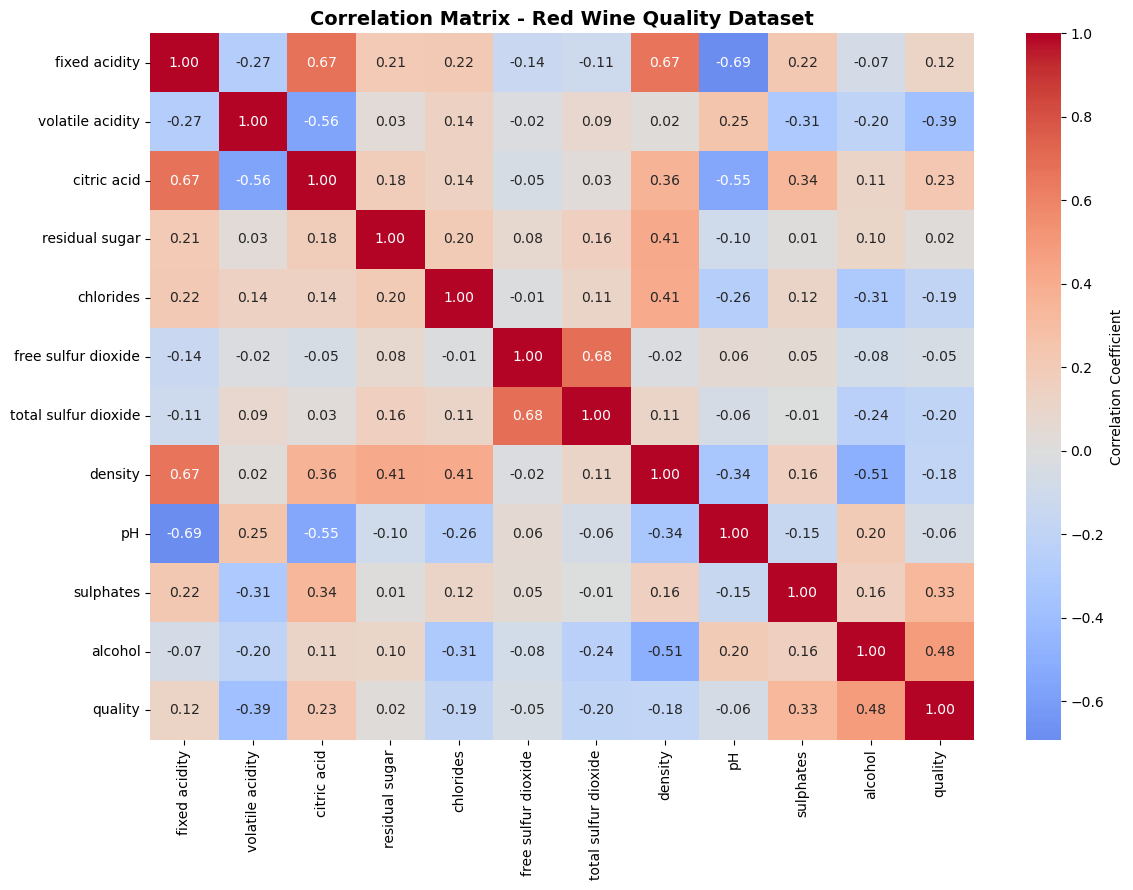

In [9]:
# Create correlation heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix - Red Wine Quality Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Key Correlation Insights:**

The correlation analysis reveals that **alcohol** (0.485), **sulphates** (0.331), and **citric acid** (0.231) show the strongest positive associations with wine quality. These three variables are likely to be the most predictive features in our regression model. Conversely, **volatile acidity** (-0.388) and **total sulfur dioxide** (-0.198) exhibit the strongest negative correlations with quality, indicating that higher levels of these compounds are associated with lower quality ratings. This asymmetry suggests that reducing volatile acidity and controlling sulfur dioxide levels are critical factors in improving wine quality.

In [10]:
# Identify multicollinearity risks: pairs with |correlation| > 0.65
multicollinearity_pairs = []
predictor_corr = corr_matrix.drop('quality', axis=0).drop('quality', axis=1)

# Loop through upper triangle of correlation matrix to avoid duplicates
for i in range(len(predictor_corr.columns)):
    for j in range(i + 1, len(predictor_corr.columns)):
        var1 = predictor_corr.columns[i]
        var2 = predictor_corr.columns[j]
        corr_val = predictor_corr.iloc[i, j]
        
        if abs(corr_val) > 0.65:
            multicollinearity_pairs.append({
                'Variable 1': var1,
                'Variable 2': var2,
                'Correlation': round(corr_val, 3)
            })

if multicollinearity_pairs:
    multicollinearity_df = pd.DataFrame(multicollinearity_pairs)
    print("Multicollinearity Alert - Variable Pairs with |Correlation| > 0.65:\n")
    print(multicollinearity_df.to_string(index=False))
else:
    print("No multicollinearity risks detected (all predictor pairs have |correlation| ≤ 0.65)")

Multicollinearity Alert - Variable Pairs with |Correlation| > 0.65:

         Variable 1           Variable 2  Correlation
      fixed acidity          citric acid        0.670
      fixed acidity              density        0.665
      fixed acidity                   pH       -0.693
free sulfur dioxide total sulfur dioxide        0.685


**Multicollinearity Analysis:**

The analysis reveals four pairs of predictor variables with strong correlations (|r| > 0.65): **fixed acidity & pH** (-0.693), **free sulfur dioxide & total sulfur dioxide** (0.685), **fixed acidity & citric acid** (0.670), and **fixed acidity & density** (0.665). These high correlations indicate multicollinearity, meaning these variables contain redundant information. In the regression model, multicollinearity inflates the standard errors of coefficients, making them less reliable and harder to interpret, even though the model's overall predictive power may not suffer. Additionally, individual coefficient significance tests become unreliable. To address this, we may consider: (1) removing one variable from each highly correlated pair, (2) combining correlated variables into a composite feature, or (3) using regularization techniques (Ridge or Lasso regression) that handle multicollinearity better. For now, we will proceed with all variables, but monitor variance inflation factors (VIF) during model evaluation.

### 3. Feature & Target Preparation

In [11]:
# Separate features (X) and target (y)
X = df.drop('quality', axis=1)
y = df['quality']

# Confirm shapes
print(f"Feature matrix X shape: {X.shape}")
print(f"Target series y shape: {y.shape}")

# Confirm no target leakage
print(f"\nX columns ({len(X.columns)}): {X.columns.tolist()}")
print(f"\n'quality' in X columns? {('quality' in X.columns)}")

Feature matrix X shape: (1374, 11)
Target series y shape: (1374,)

X columns (11): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

'quality' in X columns? False


### 4. Train-Test Split

Splitting data into training and test sets prevents data leakage and allows us to evaluate model performance on unseen data, providing a realistic assessment of generalization ability. We use a 70/30 split (70% training, 30% test) because it provides sufficient training samples for the model to learn robust patterns while retaining enough test data for reliable performance evaluation. Setting random_state=42 ensures reproducibility by making the split deterministic.

In [12]:
# Split data into training and test sets (70/30 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Print sizes and percentages
total_samples = len(X)
train_pct = (len(X_train) / total_samples) * 100
test_pct = (len(X_test) / total_samples) * 100

print(f"Total samples: {total_samples}")
print(f"Training set: {len(X_train)} samples ({train_pct:.1f}%)")
print(f"Test set: {len(X_test)} samples ({test_pct:.1f}%)")
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Total samples: 1374
Training set: 961 samples (69.9%)
Test set: 413 samples (30.1%)

X_train shape: (961, 11)
X_test shape: (413, 11)
y_train shape: (961,)
y_test shape: (413,)


# Phase 3 - Exploratory Data Analysis

## 1. Target Variable Distribution

C:\Users\ANIRUDDHAN\AppData\Local\Temp\ipykernel_2208\3903793381.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='quality', palette='viridis')


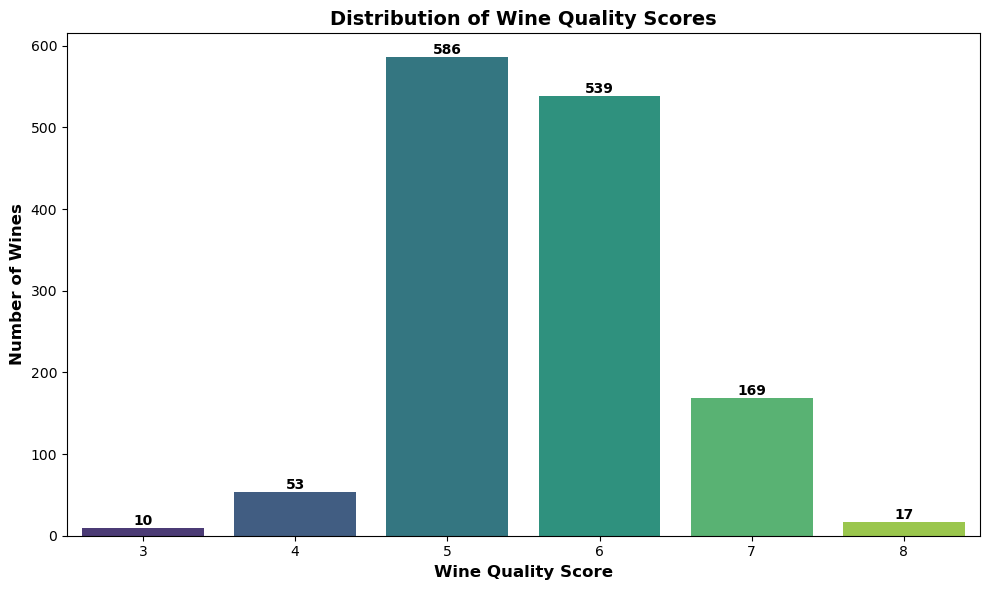

In [13]:
# Create countplot of quality distribution
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='quality', palette='viridis')

# Add count labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fontsize=10, fontweight='bold')

# Set labels and title
ax.set_xlabel('Wine Quality Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Wines', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Wine Quality Scores', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Target Distribution Analysis:**

The distribution of wine quality scores is heavily skewed toward the middle range (scores 5–6), with the vast majority of wines rated as 5 or 6, while extreme scores (3, 8) are very rare. This is not a normal distribution but rather a bimodal or concentrated distribution, indicating imbalanced class representation. For regression modeling, this distribution means the model may have difficulty predicting extreme quality values and will naturally optimize toward the central tendency; however, this is not problematic for linear regression since we are predicting continuous quality scores rather than performing classification. The skewed distribution does suggest that residual analysis and model diagnostics will be important to assess prediction accuracy across the full range of quality values.